# HSLS:09 Dropout Prediction — Modelling (Any Dropout)

This notebook trains XGBoost models across four cumulative feature tiers to predict
X4EVERDROP — whether a student ever dropped out of high school. The target variable
includes both traditional dropouts and GED/alternative completers as the positive class.
The same train/test split is used across all tiers to ensure valid comparison.

Target variable: X4EVERDROP
- 0: Never dropped out (n=13,458, 85.1%)
- 1: Dropped out at any point, including GED completers (n=2,360, 14.9%)

In [ ]:
%run 05_functions_for_modelling.ipynb

In [ ]:
import joblib

In [ ]:
df = pd.read_csv('hsls_clean.csv')

with open('train_test_split.json') as f:
    split = json.load(f)

with open('feature_tiers.json') as f:
    feature_tiers = json.load(f)

train_idx = split['train']
test_idx  = split['test']

In [ ]:
y_train = df.loc[train_idx, 'X4EVERDROP']
y_test  = df.loc[test_idx,  'X4EVERDROP']

print(f"Train dropout rate: {y_train.mean():.4f}")
print(f"Test dropout rate:  {y_test.mean():.4f}")
print(f"Train n: {len(y_train)}, dropouts: {y_train.sum()}")
print(f"Test n:  {len(y_test)},  dropouts: {y_test.sum()}")

# Tier 1 — Coarse Search

In [ ]:
tier1_search, X_train_tier1, y_train_tier1, X_test_tier1, y_test_tier1 = fit_models(
    features=feature_tiers['tier1'], df=df, train_idx=train_idx, test_idx=test_idx)

print("Best params:", tier1_search.best_params_)
print("Best CV F1:", round(tier1_search.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.6, 'n_estimators': 750, 'max_depth': 7, 'learning_rate': 0.005, 'colsample_bytree': 0.7}
Best CV F1: 0.5137


# Tier 1 — Fine Search

In [ ]:
fine_grid_tier1 = define_fine_grid(tier1_search.cv_results_)
tier1_fine_search = fit_fine_search(fine_grid_tier1, X_train_tier1, y_train_tier1)

Score range: 0.4477 — 0.5137
Threshold: 0.5005 (16 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
4          0.513746        0.008695                 750                7                0.005              0.6                     0.7
75         0.513169        0.010957                1000                6                0.005              0.6                     1.0
89         0.512398        0.010279                 100                8                0.050              0.8                     0.7
88         0.509692        0.007781                 300                7                0.010              0.7                     0.9
8          0.508961        0.010500                1000                7                0.005              1.0                     0.8
56         0.508059        0.020297                 200               10                0.005              0

# Tier 2 — Coarse Search

In [ ]:
tier2_search, X_train_tier2, y_train_tier2, X_test_tier2, y_test_tier2 = fit_models(
    features=feature_tiers['tier2'], df=df, train_idx=train_idx, test_idx=test_idx)

print("Best params:", tier2_search.best_params_)
print("Best CV F1:", round(tier2_search.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.6, 'n_estimators': 750, 'max_depth': 7, 'learning_rate': 0.005, 'colsample_bytree': 0.7}
Best CV F1: 0.5143


# Tier 2 — Fine Search

In [ ]:
fine_grid_tier2 = define_fine_grid(tier2_search.cv_results_)
tier2_fine_search = fit_fine_search(fine_grid_tier2, X_train_tier2, y_train_tier2)

Score range: 0.4637 — 0.5143
Threshold: 0.5042 (19 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
4          0.514268        0.010234                 750                7                0.005              0.6                     0.7
10         0.512903        0.014144                 200                8                0.050              1.0                     0.6
62         0.512587        0.015379                 300               10                0.010              0.8                     0.6
75         0.511920        0.009150                1000                6                0.005              0.6                     1.0
60         0.511447        0.018528                 500               10                0.010              0.6                     0.5
83         0.510475        0.011482                 100               10                0.050              1

# Tier 3 — Coarse Search

In [ ]:
tier3_search, X_train_tier3, y_train_tier3, X_test_tier3, y_test_tier3 = fit_models(
    features=feature_tiers['tier3'], df=df, train_idx=train_idx, test_idx=test_idx)

print("Best params:", tier3_search.best_params_)
print("Best CV F1:", round(tier3_search.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.6, 'n_estimators': 750, 'max_depth': 7, 'learning_rate': 0.005, 'colsample_bytree': 0.7}
Best CV F1: 0.5354


# Tier 3 — Fine Search

In [ ]:
fine_grid_tier3 = define_fine_grid(tier3_search.cv_results_)
tier3_fine_search = fit_fine_search(fine_grid_tier3, X_train_tier3, y_train_tier3)

Score range: 0.4664 — 0.5354
Threshold: 0.5216 (25 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
4          0.535370        0.016904                 750                7                0.005              0.6                     0.7
8          0.535158        0.014687                1000                7                0.005              1.0                     0.8
84         0.533916        0.013416                1000                6                0.005              0.9                     1.0
75         0.533444        0.012413                1000                6                0.005              0.6                     1.0
20         0.531084        0.016313                 500                6                0.010              0.9                     0.7
88         0.529325        0.009452                 300                7                0.010              0

# Tier 4 — Coarse Search

In [ ]:
tier4_search, X_train_tier4, y_train_tier4, X_test_tier4, y_test_tier4 = fit_models(
    features=feature_tiers['tier4'], df=df, train_idx=train_idx, test_idx=test_idx)

print("Best params:", tier4_search.best_params_)
print("Best CV F1:", round(tier4_search.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/anaconda3/envs/hsls_env/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 1.0, 'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.005, 'colsample_bytree': 0.8}
Best CV F1: 0.5451


# Tier 4 — Fine Search

In [ ]:
fine_grid_tier4 = define_fine_grid(tier4_search.cv_results_)
tier4_fine_search = fit_fine_search(fine_grid_tier4, X_train_tier4, y_train_tier4)

Score range: 0.4661 — 0.5451
Threshold: 0.5293 (26 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
8          0.545095        0.020159                1000                7                0.005              1.0                     0.8
89         0.544589        0.013746                 100                8                0.050              0.8                     0.7
63         0.543773        0.004907                 300                4                0.100              1.0                     0.5
75         0.543768        0.011398                1000                6                0.005              0.6                     1.0
4          0.543401        0.010958                 750                7                0.005              0.6                     0.7
88         0.541052        0.010152                 300                7                0.010              0

# Save Models and Data

In [ ]:
joblib.dump(tier1_fine_search, 'tier1_fine_search.pkl')
joblib.dump(tier2_fine_search, 'tier2_fine_search.pkl')
joblib.dump(tier3_fine_search, 'tier3_fine_search.pkl')
joblib.dump(tier4_fine_search, 'tier4_fine_search.pkl')

joblib.dump((X_train_tier1, y_train_tier1, X_test_tier1, y_test_tier1), 'data_tier1.pkl')
joblib.dump((X_train_tier2, y_train_tier2, X_test_tier2, y_test_tier2), 'data_tier2.pkl')
joblib.dump((X_train_tier3, y_train_tier3, X_test_tier3, y_test_tier3), 'data_tier3.pkl')
joblib.dump((X_train_tier4, y_train_tier4, X_test_tier4, y_test_tier4), 'data_tier4.pkl')

print("All models and data saved.")

# Evaluation of all models

In [ ]:
evaluate_model(tier1_fine_search, X_train_tier1, y_train_tier1, X_test_tier1, y_test_tier1, tier=1)
evaluate_model(tier2_fine_search, X_train_tier2, y_train_tier2, X_test_tier2, y_test_tier2, tier=2)
evaluate_model(tier3_fine_search, X_train_tier3, y_train_tier3, X_test_tier3, y_test_tier3, tier=3)
evaluate_model(tier4_fine_search, X_train_tier4, y_train_tier4, X_test_tier4, y_test_tier4, tier=4)

Tier 1 — Training Set Evaluation
Accuracy:  0.8974
ROC-AUC:   0.9653

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     10766
           1       0.61      0.89      0.72      1888

    accuracy                           0.90     12654
   macro avg       0.79      0.90      0.83     12654
weighted avg       0.92      0.90      0.90     12654

Tier 1 — Test Set Evaluation
Accuracy:  0.8344
ROC-AUC:   0.8494

              precision    recall  f1-score   support

           0       0.93      0.87      0.90      2692
           1       0.46      0.64      0.54       472

    accuracy                           0.83      3164
   macro avg       0.70      0.76      0.72      3164
weighted avg       0.86      0.83      0.85      3164

Tier 2 — Training Set Evaluation
Accuracy:  0.9373
ROC-AUC:   0.9900

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     10766
           1       0.71      0.

# Results Summary

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score

summary = []

for tier, fine_search, X_train, y_train, X_test, y_test in [
    (1, tier1_fine_search, X_train_tier1, y_train_tier1, X_test_tier1, y_test_tier1),
    (2, tier2_fine_search, X_train_tier2, y_train_tier2, X_test_tier2, y_test_tier2),
    (3, tier3_fine_search, X_train_tier3, y_train_tier3, X_test_tier3, y_test_tier3),
    (4, tier4_fine_search, X_train_tier4, y_train_tier4, X_test_tier4, y_test_tier4),
]:
    model = fine_search.best_estimator_
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    summary.append({
        'Tier': tier,
        'Features': X_test.shape[1],
        'CV F1': round(fine_search.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test Precision': round(precision_score(y_test, y_pred), 4),
        'Test Recall': round(recall_score(y_test, y_pred), 4),
        'Test F1': round(f1_score(y_test, y_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

 Tier  Features  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
    1       130 0.5207         0.8344          0.4606       0.6441   0.5371        0.8494
    2       192 0.5226         0.8439          0.4817       0.6144   0.5400        0.8532
    3       436 0.5458         0.8426          0.4799       0.6568   0.5546        0.8637
    4       833 0.5499         0.8404          0.4754       0.6758   0.5582        0.8658


# Feature Importance

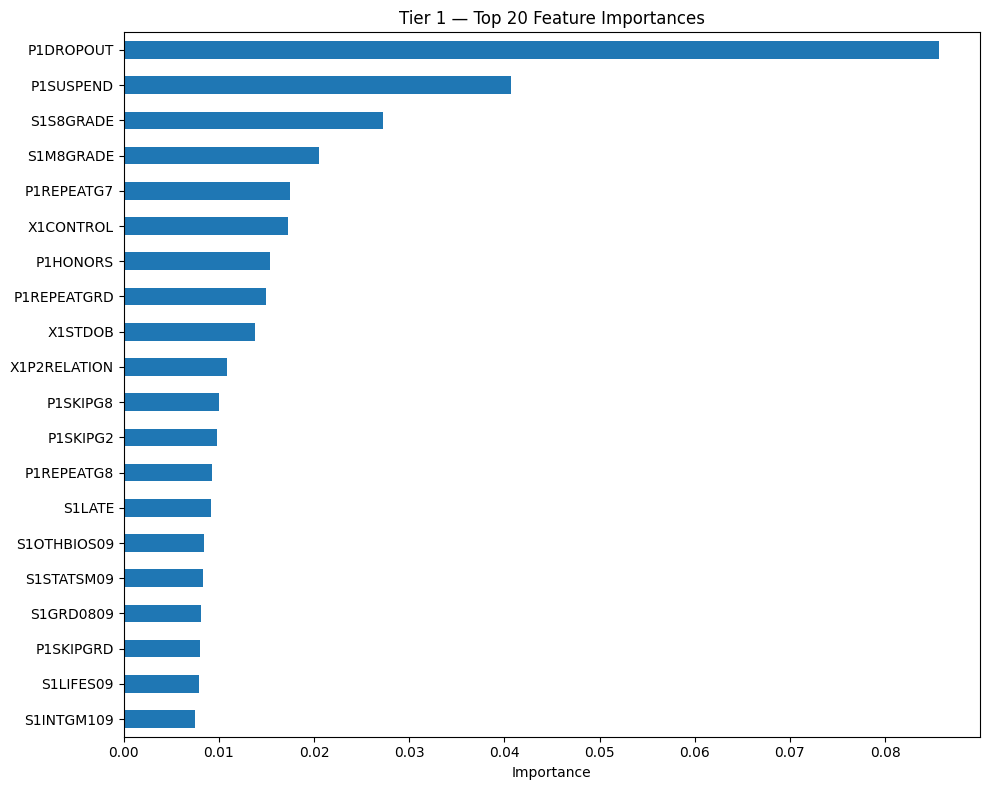

Tier 1 — Bottom 20 features:
S1EARTHS09       0.005247
P1REPEATG2       0.005213
M1CERT912        0.005172
S1ADVM09         0.005166
S1ADVPHYSIC09    0.005165
P1REPEATG3       0.005153
X1BLACK          0.005134
X1RACE           0.005123
S1OTHPHYS09      0.005099
X1P1RELATION     0.005075
P1USBORN9        0.004913
S1TRIGM09        0.004790
X1HISPANIC       0.004758
S1REVM09         0.004717
P1REPEATG6       0.004715
X1SEX            0.004696
P1DD             0.004552
S1MFALL09        0.004421
S1SFALL09        0.004143
P1REPEATG9       0.004021



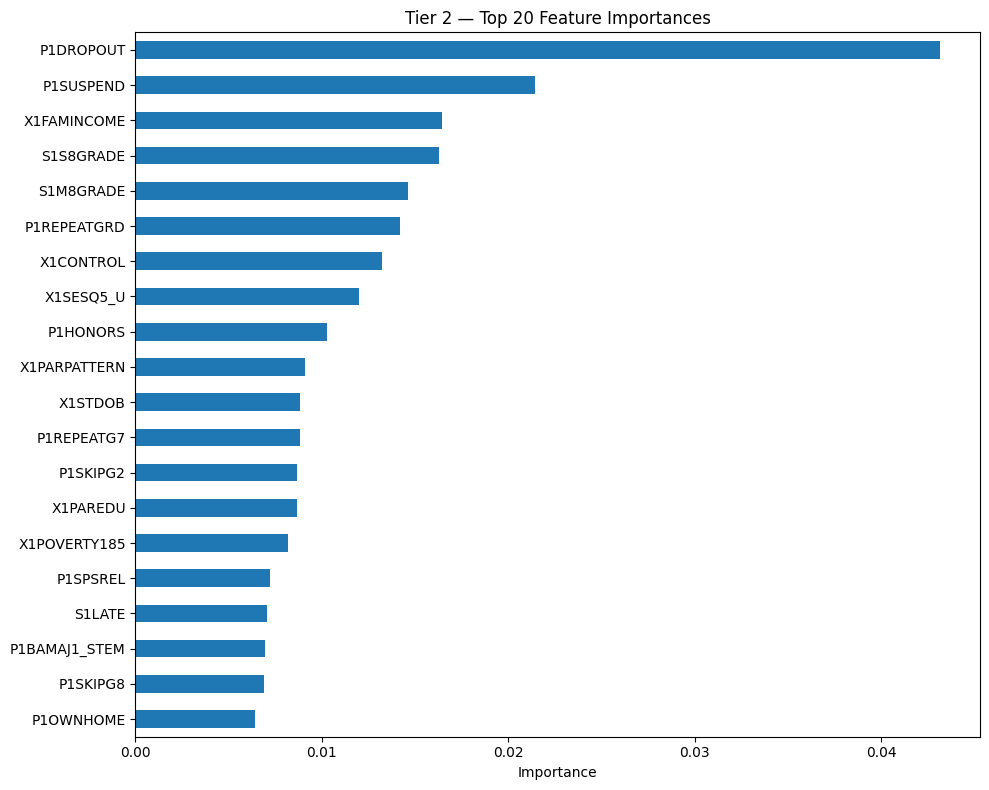

Tier 2 — Bottom 20 features:
X1BLACK        0.003604
X1WHITE        0.003593
S1PREALGM09    0.003590
X1PAR1EDU      0.003588
S1EARTHS09     0.003546
X1RACE         0.003540
A1G9TCHREF     0.003535
S1TRIGM09      0.003512
P1USBORN9      0.003495
S1SFALL09      0.003359
X1SEX          0.003357
S1REVM09       0.003353
S1INTGM209     0.003349
P1HHPARENT     0.003301
S1MFALL09      0.003233
X1HISPANIC     0.003144
P1JOBEVER2     0.003004
S1ANGEOM09     0.002742
P1JOBEVER1     0.002735
S1ADVM09       0.002229



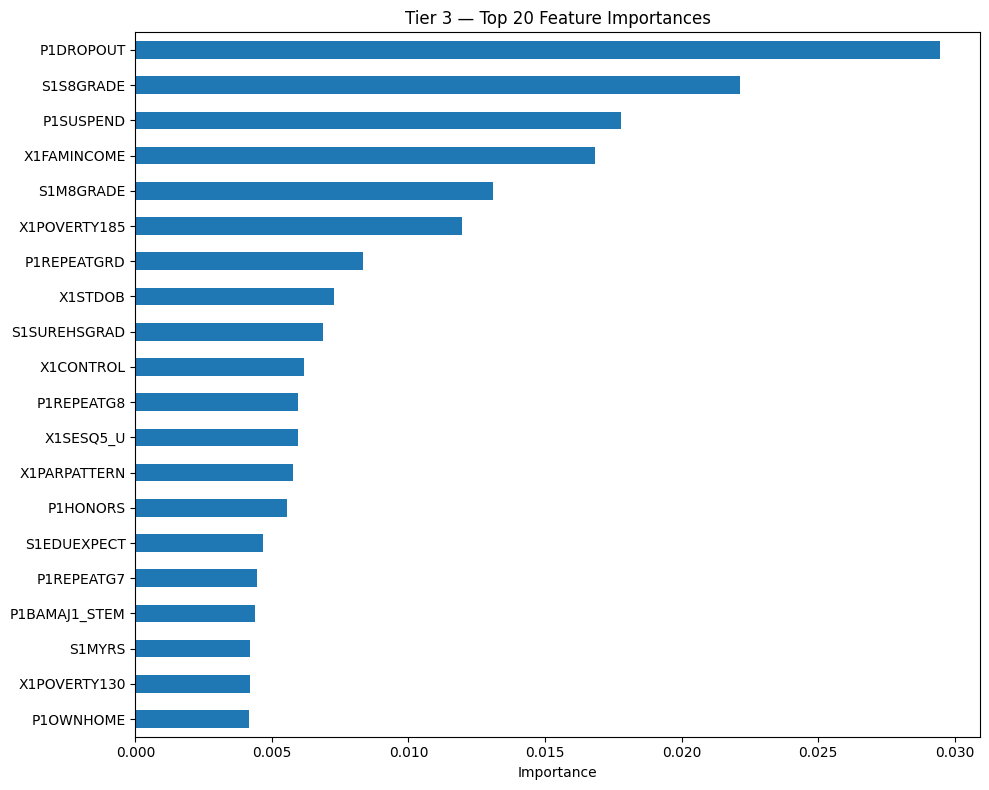

Tier 3 — Bottom 20 features:
C1PRNTREFER      0.001345
X1BLACK          0.001333
X1PAR1EDU        0.001284
S1NOTALKCLG      0.001281
S1MFALL09        0.001236
P1INTELLECT      0.001231
P1REPEATG6       0.001231
X1MOMREL         0.001222
S1OTHPHYS09      0.001222
S1INTGM209       0.001215
P1SKIPGK         0.001211
S1GENS09         0.001160
S1OTHBIOS09      0.001116
X1HISPANIC       0.001017
X1DUALLANG       0.000923
S1REVM09         0.000880
S1ADVM09         0.000791
S1TRIGM09        0.000790
P1JOBEVER1       0.000425
S1ADVPHYSIC09    0.000000



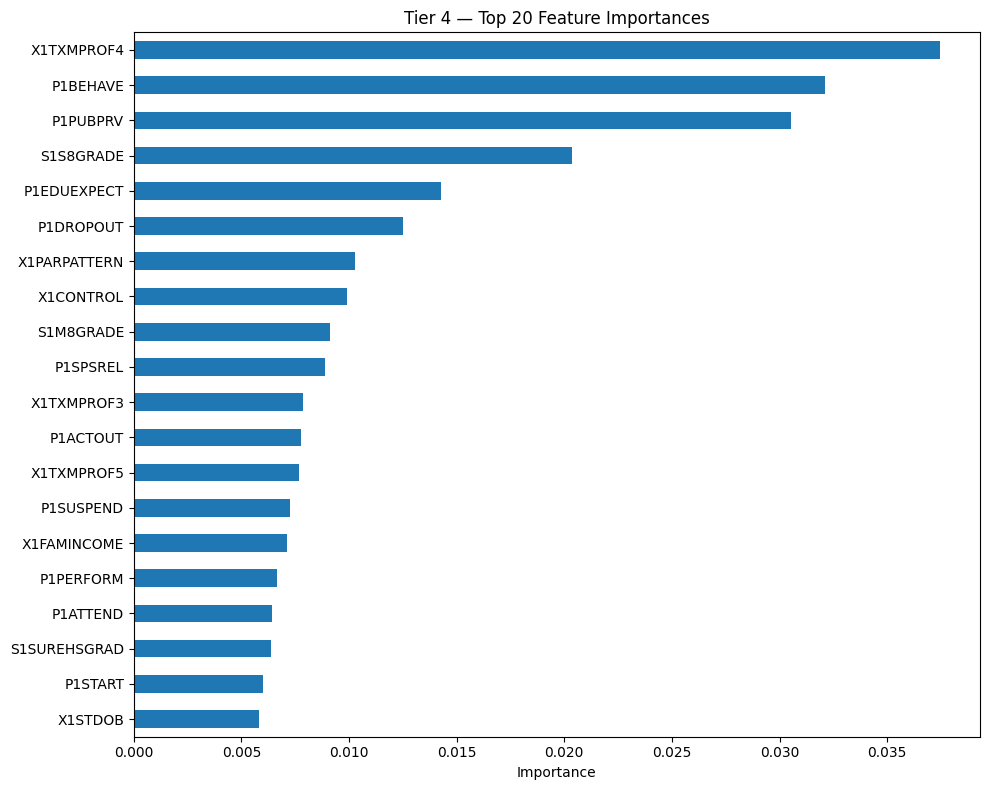

Tier 4 — Bottom 20 features:
P1CAMPMS        0.0
P1QHELP         0.0
P1PREPPAY       0.0
P1HELPPAY       0.0
P1FEEOUT        0.0
P1ADMITREQ      0.0
P1ABLEBA        0.0
P1STEMDISC      0.0
P1NOOUTSCH      0.0
P1RELIGGRP      0.0
P1ADHD          0.0
P1ARTS          0.0
P1COUNSELOR     0.0
P1SCHCHOICE     0.0
P1SKIPG3        0.0
P1SKIPG1        0.0
P1SKIPGK        0.0
P1FRIEND        0.0
P1LEARN         0.0
C1BAMAJ_STEM    0.0



In [ ]:
show_feature_importance(tier1_fine_search, X_train_tier1, tier=1)
show_feature_importance(tier2_fine_search, X_train_tier2, tier=2)
show_feature_importance(tier3_fine_search, X_train_tier3, tier=3)
show_feature_importance(tier4_fine_search, X_train_tier4, tier=4)

# Feature Importance Comparison Across Tiers

In [ ]:
compare_feature_importance(
    [tier1_fine_search, tier2_fine_search, tier3_fine_search, tier4_fine_search],
    [X_train_tier1, X_train_tier2, X_train_tier3, X_train_tier4])

Feature overlap across tiers (top 20 each):
Feature                     T1   T2   T3   T4  Tiers
--------------------------------------------------
P1DROPOUT                    1    1    1    6      4
X1STDOB                      9   11    8   20      4
X1CONTROL                    6    7   10    8      4
P1SUSPEND                    2    2    3   14      4
S1S8GRADE                    3    4    2    4      4
S1M8GRADE                    4    5    5    9      4
P1REPEATGRD                  8    6    7    -      3
X1FAMINCOME                  -    3    4   15      3
P1REPEATG7                   5   12   16    -      3
X1PARPATTERN                 -   10   13    7      3
P1HONORS                     7    9   14    -      3
P1BAMAJ1_STEM                -   18   17    -      2
P1SPSREL                     -   16    -   10      2
S1LATE                      14   17    -    -      2
X1SESQ5_U                    -    8   12    -      2
X1POVERTY185                 -   15    6    -      2
P1SK

# SHAP Analysis

Tier 1 — SHAP Summary Plot


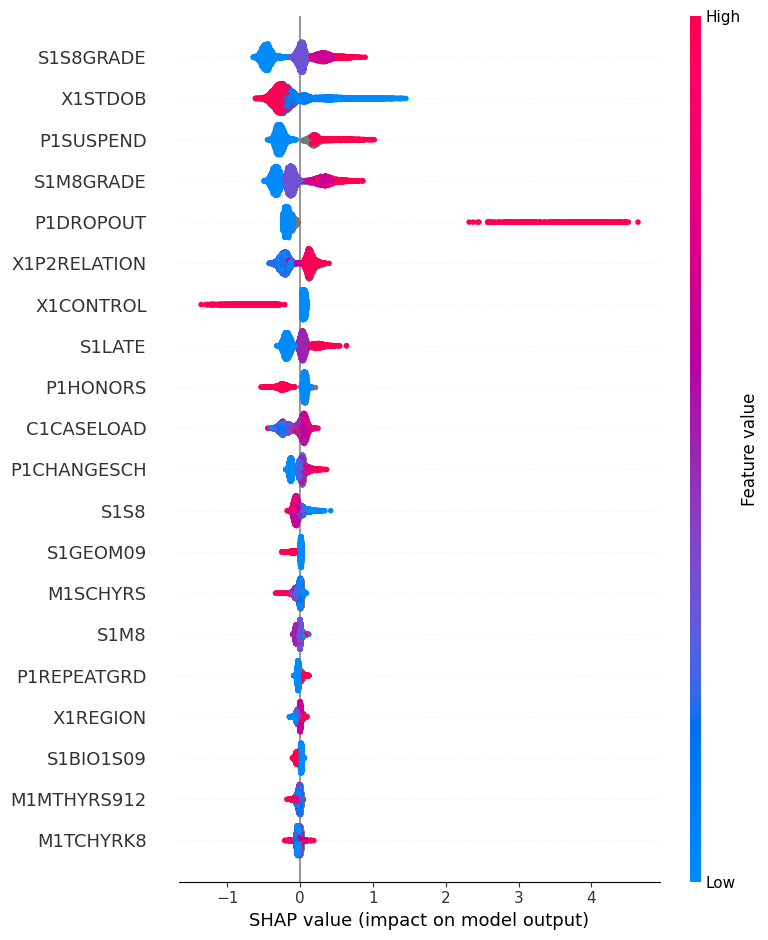

Tier 2 — SHAP Summary Plot


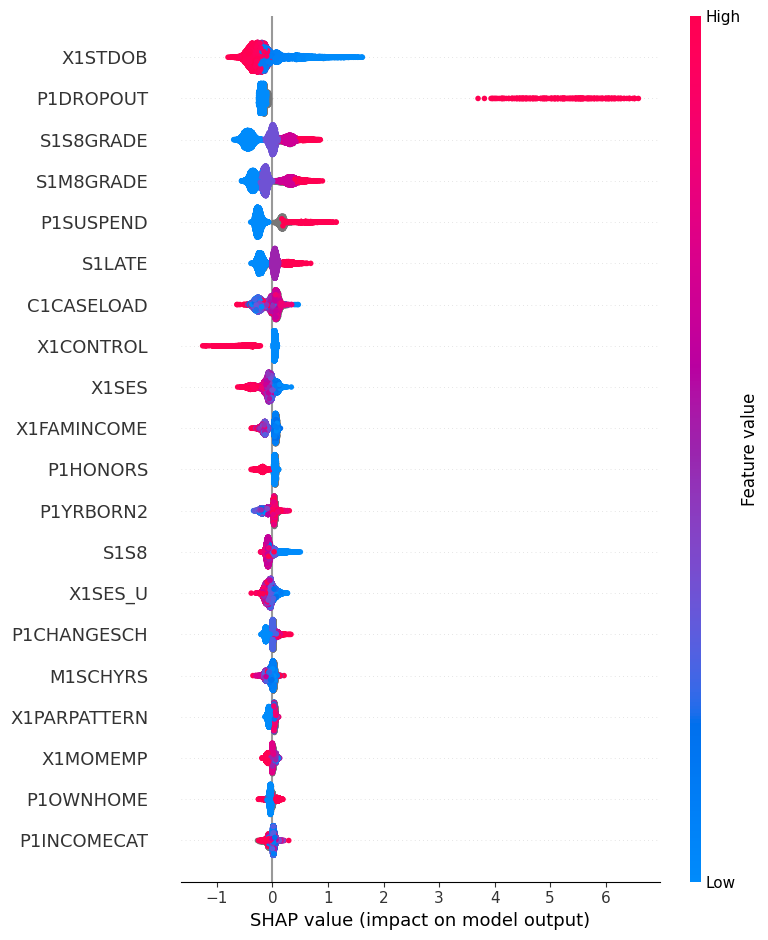

Tier 3 — SHAP Summary Plot


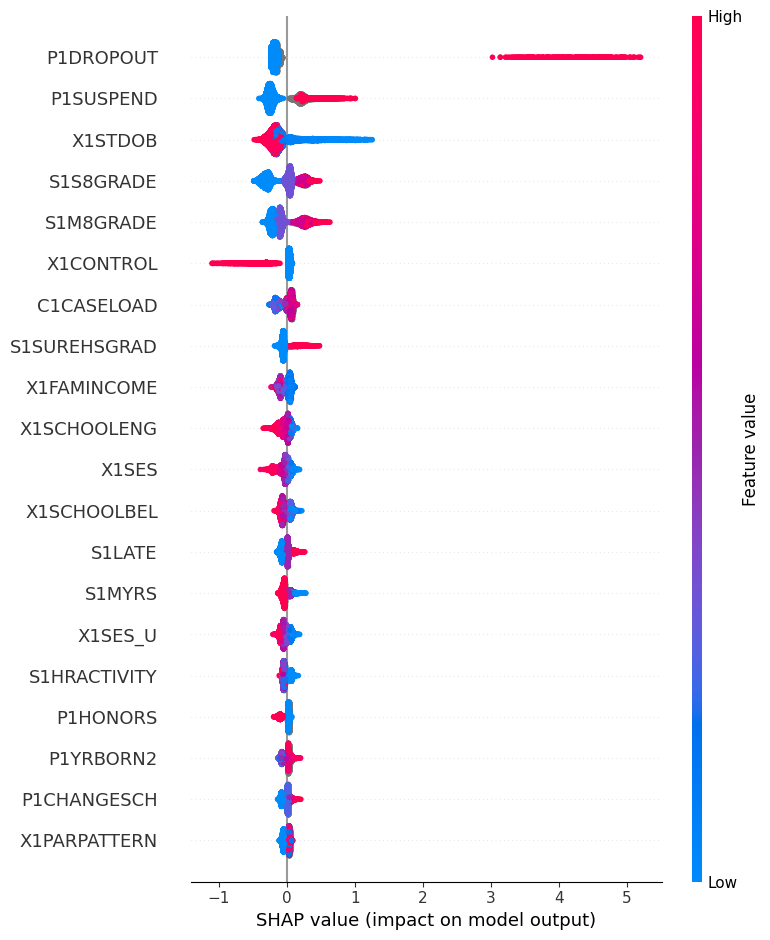

Tier 4 — SHAP Summary Plot


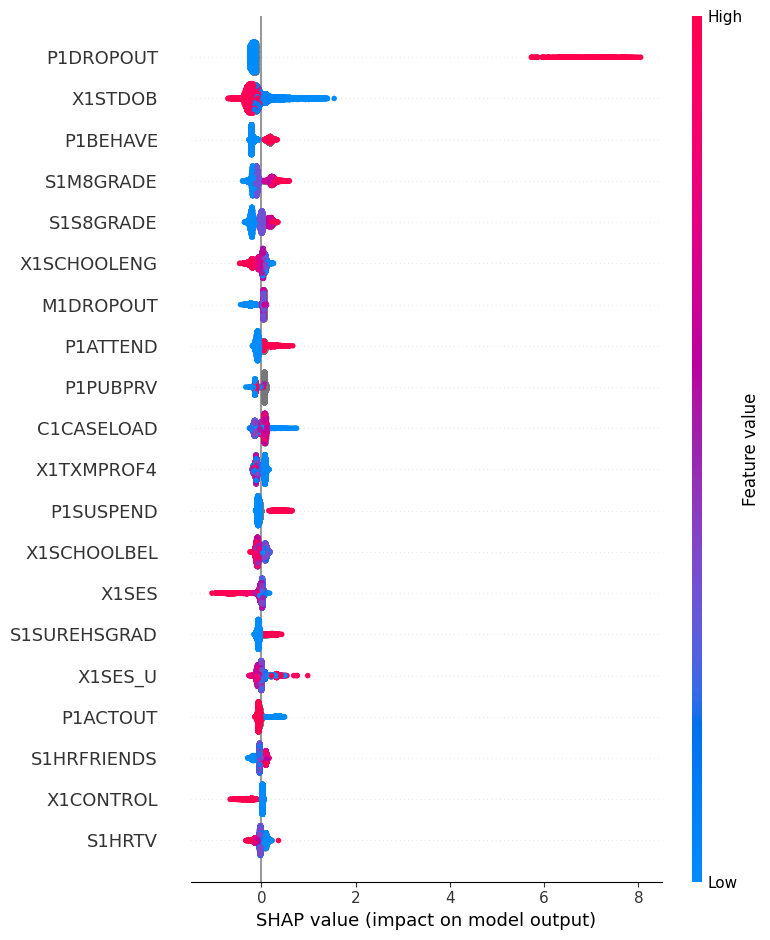

In [ ]:
plot_shap(tier1_fine_search, X_train_tier1, tier=1)
plot_shap(tier2_fine_search, X_train_tier2, tier=2)
plot_shap(tier3_fine_search, X_train_tier3, tier=3)
plot_shap(tier4_fine_search, X_train_tier4, tier=4)

# Precision-Recall Curves

In [ ]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (tier, fine_search, X_test, y_test) in enumerate([
    (1, tier1_fine_search, X_test_tier1, y_test_tier1),
    (2, tier2_fine_search, X_test_tier2, y_test_tier2),
    (3, tier3_fine_search, X_test_tier3, y_test_tier3),
    (4, tier4_fine_search, X_test_tier4, y_test_tier4),
]):
    model = fine_search.best_estimator_
    y_prob = model.predict_proba(X_test)[:, 1]
    precisions, recalls, _ = precision_recall_curve(y_test, y_prob)
    axes[i].plot(recalls, precisions)
    axes[i].set_title(f'Tier {tier}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].grid(True)

plt.suptitle('Precision-Recall Curves by Tier')
plt.tight_layout()
plt.show()

=== Probability Averaging Ensemble ===

Threshold 0.3:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82      2692
           1       0.35      0.85      0.49       472

    accuracy                           0.74      3164
   macro avg       0.66      0.78      0.66      3164
weighted avg       0.87      0.74      0.77      3164


Threshold 0.4:
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      2692
           1       0.42      0.76      0.54       472

    accuracy                           0.81      3164
   macro avg       0.68      0.79      0.71      3164
weighted avg       0.87      0.81      0.83      3164


Threshold 0.5:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2692
           1       0.50      0.65      0.57       472

    accuracy                           0.85      3164
   macro avg       0.72      0.77      0.